In [1]:

import pandas as pd
import numpy as np



Part_1
• How many observations are in the dataset?
    86 observations
• How many variables are there?
    12 variables
• What does one row represent?
    A students response
• What does each column represent?
    the questions asked in the survey
• Which variables appear to be numerical?
    proficiencies, temperature, states visited
• Which variables appear to be categorical?
    Type of phone, years since degree, SQL use, favorite seasons
• Which variables contain free-form text?
    undergrad, hours slept, fav sport, temp (some)
• Are there variables whose current data type does not match what the variable actually represents?
    Temperature, states visited - people put txt instead of int. 
• Are there missing values?
    Technically no, but people put NaN for items and that could be considered a missing value... right?

In [2]:
our_data=pd.read_csv("DS6021_F26_Class Data.csv")
our_data.head()

,Timestamp,What was your undergraduate major?,What type of phone do you have?,How many years ago did you receive your undergraduate degree?,How many hours do you sleep in a typical night?,Rate your proficiency with git/github,Rate your proficiency with Python,Have you ever used SQL?,What is your favorite sport to watch on tv?,What is your ideal outdoor temperature (in Fahrenheit)?,How many US states have you visited?,What is your favorite season?
0,2026/08/25 8:20:42 AM AST,Psychology,iPhone,4-6 years,8,3,2,Yes,F1 motorsport,70,8,Fall
1,2026/08/25 9:35:50 AM AST,Statistics,iPhone,1-3 years,8,3,4,Yes,NaN,70,16,Fall
2,2026/08/25 1:43:22 PM AST,Economics-Business and Applied Mathematics,iPhone,< 1 year,8,3,3,No,Baseball,70,27,Fall
3,2026/08/25 3:11:38 PM AST,Data Science (concentration in Computer Science),iPhone,< 1 year,8,3,4,Yes,Football (go Bears!),73,9,Fall
4,2026/08/25 3:26:11 PM AST,Math and Physics,iPhone,1-3 years,8,2,4,Yes,Figure Skating,73,26,Fall


In [ ]:
data_dict = pd.DataFrame ({
    "Variable": our_data.columns, 
    "Description": ["timestamp", "undergrad degree", "phone type", "years since undergrad", "hours slept", "git proficiency", "python proficiency", "SQL experience", "favorite sport on tv", "ideal temp outdoors", "states visited", "favorite season"],
    "Original Type": our_data.dtypes.to_list(),
    'Desired Type': ["datetime", "category", "category", "category", "integer", "integer", "integer", "boolean", "category", "integer", "integer", "category"],
})
data_dict
#I understand better in hindsight

,Variable,Description,Original Type,Desired Type
0,Timestamp,timestamp,str,datetime
1,What was your undergraduate major?,undergrad degree,str,category
2,What type of phone do you have?,phone type,str,category
3,How many years ago did you receive your underg...,years since undergrad,str,category
4,How many hours do you sleep in a typical night?,hours slept,str,integer
5,Rate your proficiency with git/github,git proficiency,int64,integer
6,Rate your proficiency with Python,python proficiency,int64,integer
7,Have you ever used SQL?,SQL experience,str,boolean
8,What is your favorite sport to watch on tv?,favorite sport on tv,str,category
9,What is your ideal outdoor temperature (in Fah...,ideal temp outdoors,str,integer


In [ ]:
#assisted to save time from typing
df = our_data.rename(columns={
    "Timestamp": "timestamp",
    "What was your undergraduate major?": "major",
    "What type of phone do you have?": "phone",
    "How many years ago did you receive your undergraduate degree?": "years_since_degree",
    "How many hours do you sleep in a typical night?": "sleep_hrs",
    "Rate your proficiency with git/github": "git_prof",
    "Rate your proficiency with Python": "python_prof",
    "Have you ever used SQL?": "used_sql",
    "What is your favorite sport to watch on tv?": "fav_sport",
    "What is your ideal outdoor temperature (in Fahrenheit)? ": "fav_temp",
    "How many US states have you visited?": "states_visited",
    "What is your favorite season?": "season",
})
df.columns 

Index(['timestamp', 'major', 'phone', 'years_since_degree', 'sleep_hrs',
       'git_prof', 'python_prof', 'used_sql', 'fav_sport', 'fav_temp',
       'states_visited', 'season'],
      dtype='str')

In [5]:
df.head()

,timestamp,major,phone,years_since_degree,sleep_hrs,git_prof,python_prof,used_sql,fav_sport,fav_temp,states_visited,season
0,2026/08/25 8:20:42 AM AST,Psychology,iPhone,4-6 years,8,3,2,Yes,F1 motorsport,70,8,Fall
1,2026/08/25 9:35:50 AM AST,Statistics,iPhone,1-3 years,8,3,4,Yes,NaN,70,16,Fall
2,2026/08/25 1:43:22 PM AST,Economics-Business and Applied Mathematics,iPhone,< 1 year,8,3,3,No,Baseball,70,27,Fall
3,2026/08/25 3:11:38 PM AST,Data Science (concentration in Computer Science),iPhone,< 1 year,8,3,4,Yes,Football (go Bears!),73,9,Fall
4,2026/08/25 3:26:11 PM AST,Math and Physics,iPhone,1-3 years,8,2,4,Yes,Figure Skating,73,26,Fall


In [6]:
df['timestamp'].head()
df['timestamp'] = df['timestamp'].str.replace("AST", " ")
df['timestamp'].head()
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['timestamp'].head()


0   2026-08-25 08:20:42
1   2026-08-25 09:35:50
2   2026-08-25 13:43:22
3   2026-08-25 15:11:38
4   2026-08-25 15:26:11
Name: timestamp, dtype: datetime64[us]

In [7]:
df['major'].value_counts()
df['major'].nunique()
df['major'] = df['major'].str.strip()
df['major'] = df['major'].str.title()
df['major'].nunique()
df['major'].to_list()
#pain

['Psychology',
 'Statistics',
 'Economics-Business And Applied Mathematics',
 'Data Science (Concentration In Computer Science)',
 'Math And Physics',
 'Analytics',
 'Statistics',
 'Statistics And Media Studies',
 'Computer Science',
 'Economics',
 'Commerce',
 'Economics',
 'Computer Science',
 'Computer Science',
 'Computer Science',
 'Biology Ba',
 'Astrophysics',
 'Economics',
 'Communications',
 'Cognitive Science',
 'Cognitive Science, Computer Science Concentration',
 'Economics',
 'Statistics',
 'Applied Statistics',
 'Economics',
 'Statistics',
 'B.A. In Computer Science',
 'Computational Modeling And Data Analytics',
 'Economics',
 'Psychology And Economics',
 'Statistics And Economics',
 'Economics',
 'Statistics',
 'Astronomy-Physics',
 'Mathematics',
 'Applied Mathematics',
 'Computational Applied Mathematics And Statistics, Data Science Minor',
 'English',
 'Data Science',
 'Data Science/Mathematics',
 'Computer Science',
 'Math And Computer Science',
 'Computer Science',

In [8]:
df['phone'].tolist()
df['phone'].value_counts(dropna=False)
df['phone'] = df['phone'].astype('category')
df['phone'].dtype

CategoricalDtype(categories=['Android', 'iPhone'], ordered=False, categories_dtype=str)

In [9]:
df.dtypes
df['years_since_degree'] = df['years_since_degree'].astype('category')
df.dtypes


timestamp             datetime64[us]
major                            str
phone                       category
years_since_degree          category
sleep_hrs                        str
git_prof                       int64
python_prof                    int64
used_sql                         str
fav_sport                        str
fav_temp                         str
states_visited                   str
season                           str
dtype: object

In [10]:

df['sleep_hrs'].value_counts(dropna=False)
df['sleep_hrs'] = df['sleep_hrs'].astype(str).str[0]
df['sleep_hrs'].value_counts(dropna=False)
df.loc[df['sleep_hrs'] == "a", 'sleep_hrs'] = '7'
df.loc[df['sleep_hrs'] == "0", 'sleep_hrs'] = '4'
df.loc[df['sleep_hrs'] == "1", 'sleep_hrs'] = '8'
df['sleep_hrs'].value_counts(dropna=False)
df['sleep_hrs'] = df['sleep_hrs'].astype(int)
df.dtypes




timestamp             datetime64[us]
major                            str
phone                       category
years_since_degree          category
sleep_hrs                      int64
git_prof                       int64
python_prof                    int64
used_sql                         str
fav_sport                        str
fav_temp                         str
states_visited                   str
season                           str
dtype: object

In [11]:
df['used_sql'] = our_data['Have you ever used SQL?'].map({'Yes': True, "No": False})
df['used_sql'].to_list()
df.dtypes


timestamp             datetime64[us]
major                            str
phone                       category
years_since_degree          category
sleep_hrs                      int64
git_prof                       int64
python_prof                    int64
used_sql                        bool
fav_sport                        str
fav_temp                         str
states_visited                   str
season                           str
dtype: object

In [12]:
df['fav_sport'].value_counts(dropna=False)

fav_sport
Football                                             18
Basketball                                            9
Soccer                                                8
Baseball                                              5
NaN                                                   2
Basketball                                            2
Soccer                                                2
College Basketball                                    2
soccer                                                2
College Football                                      2
Cricket                                               2
Hockey                                                2
F1 motorsport                                         1
Football (go Bears!)                                  1
Figure Skating                                        1
None!                                                 1
College Hoops                                         1
College football                      

In [13]:
#leaning into Ai for this one
df['fav_sport'].value_counts(dropna=False)
df['fav_sport'].nunique()
df['fav_sport'] = (df['fav_sport'].astype(str).str.strip().str.lower())
df['fav_sport'].nunique()

def group_sport(text):
    t = str(text)

    if t in ("nan", "none!", "na", "i don't watch tv", "i don't watch sports"):
        return "None"
    if "football" in t or "superbowl" in t:
        return "Football"
    if "basket" in t or "hoops" in t:
        return "Basketball"
    if "soccer" in t or "fustal" in t or "futsal" in t:
        return "Soccer"
    if "baseball" in t or "softwball" in t:
        return "Baseball"
    if "hockey" in t:
        return "Hockey"
    return "Other"

df["sport_group"] = df["fav_sport"].map(group_sport)
df["sport_group"] = df["sport_group"].astype("category")
df["sport_group"].value_counts()

sport_group
Football      32
Basketball    15
Soccer        13
Other         12
Baseball       6
Hockey         5
None           3
Name: count, dtype: int64

In [14]:
#assisted
df['fav_temp'].value_counts(dropna=False)
temp_raw = df['fav_temp'].copy()
df['fav_temp'] = pd.to_numeric(temp_raw, errors="coerce")
df['fav_temp'].value_counts(dropna=False)
temp_raw[df["fav_temp"].isna()]
df['fav_temp'].value_counts(dropna=False)


fav_temp
70.0    12
NaN     10
68.0    10
73.0     8
75.0     8
65.0     7
72.0     5
77.0     4
64.0     3
78.0     3
55.0     2
80.0     2
85.0     2
74.0     2
76.0     1
71.0     1
57.0     1
79.0     1
40.0     1
67.0     1
60.0     1
63.0     1
Name: count, dtype: int64

In [15]:
#AI for time
df.loc[temp_raw == "70 degrees", "fav_temp"] = 70
df.loc[temp_raw == "63 degrees", "fav_temp"] = 63
df.loc[temp_raw == "40 degrees", "fav_temp"] = 40
df.loc[temp_raw == "70's", "fav_temp"] = 70
df.loc[temp_raw == "70-85", "fav_temp"] = 78
df.loc[temp_raw == "High sixties", "fav_temp"] = 68
df.loc[temp_raw == "Mid 70's", "fav_temp"] = 75
df.loc[temp_raw == "75 slightly sunny", "fav_temp"] = 75
df.loc[temp_raw == "75 F", "fav_temp"] = 7

df["fav_temp"].isna().sum()
df["fav_temp"].describe()
temp_raw[df["fav_temp"].isna()]
df['fav_temp'].value_counts(dropna=False)


fav_temp
70.0    15
68.0    10
75.0     9
73.0     8
65.0     7
72.0     5
78.0     4
77.0     4
64.0     3
55.0     2
80.0     2
85.0     2
74.0     2
63.0     2
NaN      2
40.0     2
76.0     1
71.0     1
57.0     1
79.0     1
67.0     1
60.0     1
7.0      1
Name: count, dtype: int64

In [16]:
df.dtypes
#Assisted
states_raw = df["states_visited"].copy()
df["states_visited"] = pd.to_numeric(states_raw, errors="coerce")
states_raw[df["states_visited"].isna()]
df.loc[states_raw.str.contains("35-40", na=False), "states_visited"] = 38
df.loc[states_raw.str.contains("25-30", na=False), "states_visited"] = 28
df.loc[states_raw.str.contains("25ish", na=False), "states_visited"] = 25
df.loc[states_raw.str.contains("10+", na=False), "states_visited"] = 10
df.loc[states_raw.str.contains("around 35", na=False), "states_visited"] = 35
df.loc[states_raw.str.contains("If I had to guess", na=False), "states_visited"] = 23
df.loc[states_raw.str.contains("9 states", na=False), "states_visited"] = 9
df.loc[states_raw.str.contains("east coast", na=False), "states_visited"] = 14
df.loc[states_raw.str.contains("all except", case=False, na=False), "states_visited"] = 47
df.loc[states_raw.str.contains("No clue", case=False, na=False), "states_visited"] = 30

df["states_visited"].isna().sum()
df["states_visited"].describe()

df.dtypes

timestamp             datetime64[us]
major                            str
phone                       category
years_since_degree          category
sleep_hrs                      int64
git_prof                       int64
python_prof                    int64
used_sql                        bool
fav_sport                        str
fav_temp                     float64
states_visited               float64
season                           str
sport_group                 category
dtype: object

In [17]:
df["season"] = df["season"].astype("category")
df.dtypes

timestamp             datetime64[us]
major                            str
phone                       category
years_since_degree          category
sleep_hrs                      int64
git_prof                       int64
python_prof                    int64
used_sql                        bool
fav_sport                        str
fav_temp                     float64
states_visited               float64
season                      category
sport_group                 category
dtype: object

Variable = V
Issue = I
Transformation = T

V- timestap
I- text and AST
T- stripped AST and switched to datetime


V- sleep_hrs
I- some people threw in some non-integers 
T- i took only the first character then input the other

V- fav_sport
I- people put multiple answers and wrote sentences 
T- i used ai here to help, it iterated through each text searching for key words and returned the first sport that is was propmted to grab


### End of Part 2

In [18]:
df.describe()




,timestamp,sleep_hrs,git_prof,python_prof,fav_temp,states_visited
count,86,86.000000,86.000000,86.000000,84.000000,86.000000
mean,2026-08-26 09:24:26.453488,7.232558,2.662791,3.069767,69.369048,17.046512
min,2026-08-25 08:20:42,4.000000,1.000000,1.000000,7.000000,1.000000
25%,2026-08-26 10:12:16.500000,7.000000,2.000000,2.000000,68.000000,9.250000
50%,2026-08-26 11:04:33,7.000000,3.000000,3.000000,70.000000,15.000000
75%,2026-08-26 11:15:22.750000,8.000000,3.000000,4.000000,75.000000,22.750000
max,2026-08-26 12:16:47,9.000000,5.000000,5.000000,85.000000,48.000000
std,NaN,1.002050,1.184314,0.955365,10.092082,10.560645


Some interesting things:
sleep hours - 4 hours, insomniac in the group is odd.
git and python - show that not everyone is a professional before the program.
temp - i must have had an issue cleaning the data, unless 4 is acutually the min.
states visited - higher median/average than I thought, but one state is odd to think that someone has never left their home state, but it could be a data cleaning issue again


In [19]:
print(df["season"].value_counts(normalize = True))
print(df["sport_group"].value_counts(normalize = True))
print(df["years_since_degree"].value_counts(normalize = True))
print(df["phone"].value_counts(normalize = True, dropna=False))
print(df["used_sql"].value_counts(normalize = True))

season
Fall      0.488372
Spring    0.267442
Summer    0.151163
Winter    0.093023
Name: proportion, dtype: float64
sport_group
Football      0.372093
Basketball    0.174419
Soccer        0.151163
Other         0.139535
Baseball      0.069767
Hockey        0.058140
None          0.034884
Name: proportion, dtype: float64
years_since_degree
< 1 year      0.581395
1-3 years     0.197674
4-6 years     0.151163
7-10 years    0.046512
10+ years     0.023256
Name: proportion, dtype: float64
phone
iPhone     0.906977
Android    0.081395
NaN        0.011628
Name: proportion, dtype: float64
used_sql
True     0.639535
False    0.360465
Name: proportion, dtype: float64


Unique Categories
season - 4
sports group - 7
years since undergrad - 5
phone - 3
used sql - 2

Frequency counts
season - Fall was most frequent
sports group - football was most frequent
years since undergrad - most are from undegrad
phone - almost all have iphone
used sql - most people have experience with sql

Proportions
season - almost half favor fall
sports group - majority are Football fans
years since undergrad - majority are from undergrad
phone - iphone is the dominant phone
used sql - two-thirds have experience with sql

most common responses
season - fall
sports group - football
years since undergrad - 1
phone - iphone
used sql - yes

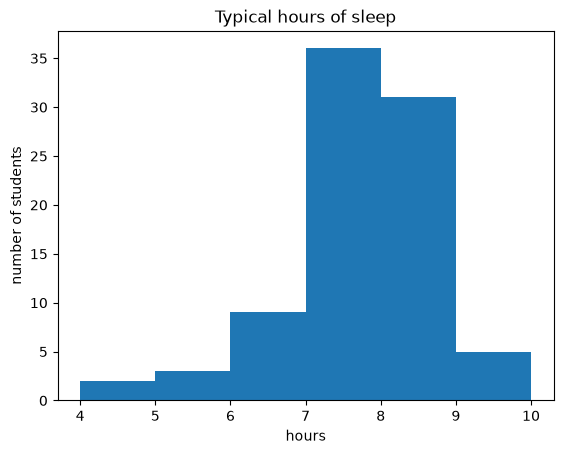

In [20]:
import matplotlib.pyplot as plt
plt.figure()
plt.hist(df['sleep_hrs'], bins=range(4,11))
plt.title('Typical hours of sleep')
plt.xlabel('hours')
plt.ylabel('number of students')
plt.show()

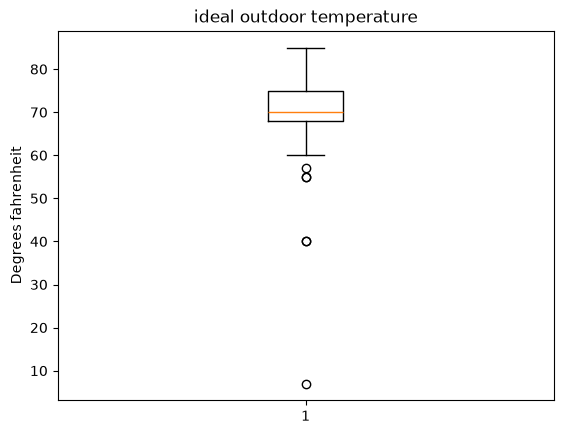

In [21]:
plt.figure()
plt.boxplot(df['fav_temp'].dropna())
plt.title("ideal outdoor temperature")
plt.ylabel("Degrees fahrenheit")
plt.show()

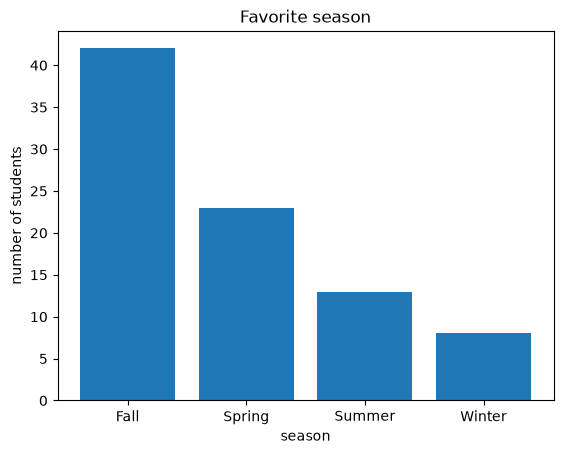

In [22]:
counts = df['season'].value_counts()
plt.figure()
plt.bar(counts.index, counts.values)
plt.title("Favorite season")
plt.xlabel('season')
plt.ylabel("number of students")
plt.show()

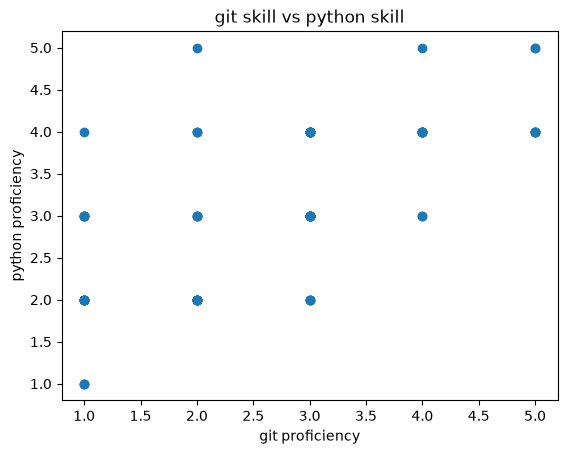

,git_prof,python_prof
git_prof,1.000000,0.655308
python_prof,0.655308,1.000000


In [23]:
plt.figure()
plt.scatter(df['git_prof'], df['python_prof'])
plt.title('git skill vs python skill')
plt.xlabel('git proficiency')
plt.ylabel('python proficiency')
plt.show()

df[['git_prof', 'python_prof']].corr()

1. Why you chose the variables.
    git and python are industry aligned. I would think there is correlation in proficiency.
2. What the visualization shows.
    it shows participants answers for git and python proficiency.
3. Whether you see evidence of an interesting relationship.
    the relationship i see is what i would expect.

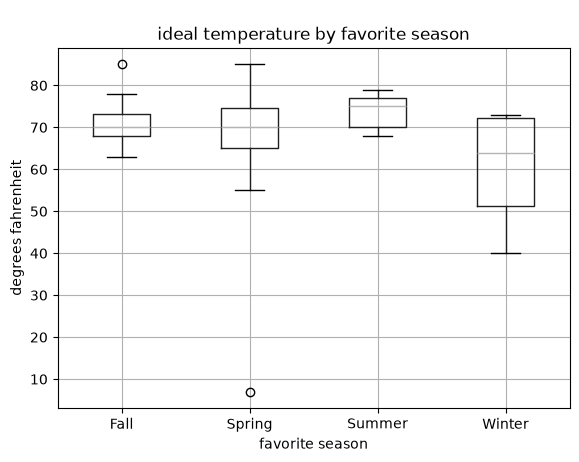

In [24]:
df.boxplot(column='fav_temp', by='season')
plt.title('ideal temperature by favorite season')
plt.suptitle(" ")
plt.xlabel('favorite season')
plt.ylabel('degrees fahrenheit')
plt.show()

1. Why you chose the variables.
    i chose them because im interested to see if people have any biases in their ideal temp vs fav season
2. What the visualization shows.
    it shows participants choices of their favorite season against their ideal temp. 
3. Whether you see evidence of an interesting relationship.
    It was funny to see winter and summer have lower and higher average temps respectively while fall and spring are very similar. interesting to vizualize but there is a soft relationship.

sport_group  Baseball  Basketball  Football  Hockey  None  Other  Soccer
season                                                                  
Fall                2           5        20       1     2      6       6
Spring              4           2         5       3     0      4       5
Summer              0           5         5       0     0      1       2
Winter              0           3         2       1     1      1       0


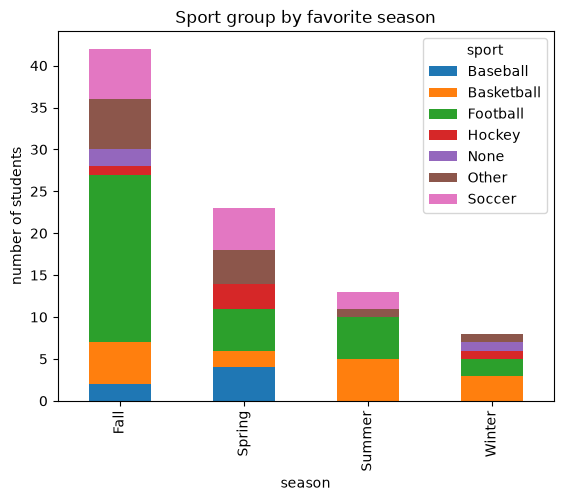

In [25]:
#assisted
ct = pd.crosstab(df['season'], df['sport_group'])
print(ct)

ct.plot(kind='bar', stacked=True)
plt.title('Sport group by favorite season')
plt.xlabel('season')
plt.ylabel('number of students')
plt.legend(title='sport')
plt.show()

1. Why you chose the variables.
    sports and weather tend to go together
2. What the visualization shows.
    for each participant in the seasons and their top sport to watch.
3. Whether you see evidence of an interesting relationship.
    it is interesting, fall and football were the largest groups and they fall exactly where we wouldve thought. odd that the bulk of hockey were spring people.

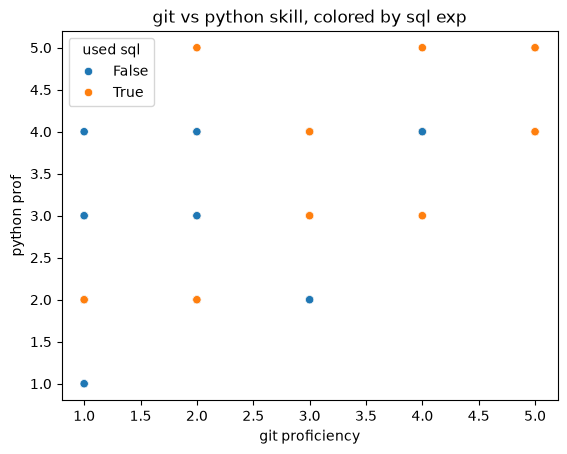

In [29]:
#assisted
import seaborn as sns

plt.figure()
sns.scatterplot(
    data=df, 
    x='git_prof',
    y='python_prof',
    hue='used_sql'
)
plt.title('git vs python skill, colored by sql exp')
plt.xlabel('git proficiency')
plt.ylabel('python prof')
plt.legend(title='used sql')
plt.show()

Describe what the additional variable reveals that was not apparent in your bivariate analysis.

We add into the graph sql experience in color. I would expect their to be a correlation of sql use with git/python proficiency due to the nature of them being in similar fields of study. We can see that the orange(true) is more apparent in the upper quadrant of the plot. 

Part 7:
Answer the following:
1. What would you like to predict?
    I would like to predict if someone has a CS major by using python, git and sql proficiency/use. 
2. Is this primarily a regression or classification problem?
    Classification, we are determining a yes or no. the vairables would be regression because they are on a scale but CS major is a true or false.
3. Identify 3–5 variables that might be useful predictors.
    python/git prof and sql use
4. Explain briefly why you think each predictor could contain useful information about the
outcome.
    I think it is self explanatory that python, git, and sql use/proficiency are likely correlated of someone having a CS background. It tends to be in the cousework
5. Are there variables you would not use as predictors? Why?
    fav sports, ideal temp, fav season. These arent correlated or i hope have none to predicting is someone is a CS major or not.
6. What data-quality or preprocessing issues would need to be addressed before fitting a model?
    I would need to address the issue of major having very ugly data. I would need to pull out anything having 'computer' or something close to it. luckily the variables are clean with int/bool data.

Raw Data −→Clean Data −→Exploration −→Prediction